# TE Flex Analysis — Parquet Pipeline

Refactored pipeline using **parquet + dask** throughout.
List columns are stored as proper Arrow `LIST<T>` types (no string serialisation),
so all `ast.literal_eval` / `isinstance(x, str)` guards have been removed.

## Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import pyarrow as pa
import xmltodict
import matplotlib.pyplot as plt
import matsim_output_analysis_experienced_te as moa

In [2]:
from dask.distributed import Client
client = Client(
    n_workers=1,
    threads_per_worker=4,
    memory_limit='18GB',
    local_directory='C:/tmp/dask-spill',  # spill to disk before killing
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 1
Total threads: 4,Total memory: 16.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:55433,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:55440,Total threads: 4
Dashboard: http://127.0.0.1:55441/status,Memory: 16.76 GiB
Nanny: tcp://127.0.0.1:55436,


2026-06-05 09:02:50,779 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 308ab15efee39282472574fc6457efc1 initialized by task ('hash-join-transfer-308ab15efee39282472574fc6457efc1', 930) executed on worker tcp://127.0.0.1:55440
2026-06-05 09:17:16,364 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle a7582fcaa170c4f9115a3fcf82157b7c initialized by task ('hash-join-transfer-a7582fcaa170c4f9115a3fcf82157b7c', 98) executed on worker tcp://127.0.0.1:55440
2026-06-05 09:19:11,095 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:55440 (pid=31468) exceeded 95% memory budget. Restarting...
2026-06-05 09:19:11,162 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:55440 (pid=31468) is slow to terminate; trying again
2026-06-05 09:19:11,208 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:55440' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('delayed-15497562f955b75c0dab527033168a0e', 0),

## Configuration

In [3]:
PLANS = {
    "sp":  "selected plan",
    "ep":  "experienced plan"
}

number_of_unselected_plans = 9
for i in range(1, number_of_unselected_plans+1):
    PLANS.update({f"up{i}": f"unselected plan ({i})"})

FIELDS = [
    "activity_type_or_mode",
    "distance_travelled",
    "duration",
    "location",
    "routes",
    "boardingTime",
]

---
## Stage 1 — Build Parquet with Native List Columns

Reads CSV sources, parses semicolon-delimited strings into proper Python lists,
computes all utility values (casting results to `float`/`int`),
and writes a parquet file whose list columns are Arrow `LIST<T>` — not strings.

### Load & Filter CSVs

In [11]:
pl_dtype = {
    'age': 'float64', 'hholdnumchildren': 'float64', 'hhsize': 'float64',
    'householdid': 'float64', 'individualid': 'float64', 'surveyyear': 'float64',
    'unselected plan (9) number': 'float64', 'unselected plan (10) number': 'float64',
    'unselected plan (11) number': 'float64', 'unselected plan (12) number': 'float64',
    'unselected plan (13) number': 'float64', 'unselected plan (14) number': 'float64',
}

# read enough rows that some survive the filters after the merge
sample_pl = pd.read_csv("1405_2040_10pc_keep10.csv", nrows=200, dtype=pl_dtype)

In [28]:
ex_keep = ["id", "selected plan activity_type_or_mode", "selected plan utility",
           "selected plan duration", "selected plan distance_travelled",
           "selected plan routes", "selected plan boardingTime", "selected plan location"]
sample_ex = pd.read_csv("0406_2040_10pc_100iters_keep20_experienced.csv", nrows=200, usecols=ex_keep)
sample_ex.columns = ["id", "experienced plan activity_type_or_mode", "experienced plan utility",
                     "experienced plan duration", "experienced plan distance_travelled",
                     "experienced plan routes", "experienced plan boardingTime", "experienced plan location"]

# replicate the same merge + filters as the Dask pipeline
sample = pd.merge(sample_pl, sample_ex, how="outer", on="id")
sample = sample[~sample["subpopulation"].isin(["hgv", "lgv", "airport", "lgv_ev"])]
sample = sample[sample["id"].notnull()]
sample = sample[sample["selected plan routes"].notnull()].reset_index(drop=True)

In [ ]:
# str.split all plan fields (same as Cell 10)
for plan_name in PLANS.values():
    for field in FIELDS:
        col = f"{plan_name} {field}"
        if col in sample.columns and  sample[col].dtype == object:
            # print(sample[col])
            sample[col] = sample[col].str.split("; ")
            # print(sample[col])


SyntaxError: invalid syntax (3968714524.py, line 5)

In [30]:
# add stuck_bool (same as _add_stuck_bool)
def to_str(x):
    try: return "; ".join(str(v) for v in x)
    except: return ""
sample["stuck_bool"] = (
    sample["selected plan activity_type_or_mode"].apply(to_str)
    != sample["experienced plan activity_type_or_mode"].apply(to_str)
).astype(int)

In [31]:
df_pl = dd.read_csv(r"1405_2040_10pc_keep10.csv", blocksize="20MB", dtype={
    'age': 'float64', 'hholdnumchildren': 'float64', 'hhsize': 'float64',
    'householdid': 'float64', 'individualid': 'float64', 'surveyyear': 'float64',
    'unselected plan (10) number': 'float64',
       'unselected plan (11) number': 'float64',
       'unselected plan (12) number': 'float64',
       'unselected plan (13) number': 'float64',
       'unselected plan (14) number': 'float64',
       'unselected plan (9) number': 'float64'
})
# df_ex = dd.read_csv(r"1405_2040_10pc_keep20_experienced.csv", blocksize="64MB")

# df_pl = dd.read_csv(r"1405_2040_0.1pc_keep20.csv",  blocksize="50MB", dtype={
#     'age': 'float64', 'hholdnumchildren': 'float64', 'hhsize': 'float64',
#     'householdid': 'float64', 'individualid': 'float64', 'surveyyear': 'float64',
#     'unselected plan (10) number': 'float64',
#        'unselected plan (11) number': 'float64',
#        'unselected plan (12) number': 'float64',
#        'unselected plan (13) number': 'float64',
#        'unselected plan (14) number': 'float64',
#        'unselected plan (9) number': 'float64'
# }, assume_missing=True) #this is the 2040 do minimum plans

# df_pl = dd.read_parquet(r"0406_2040_10pc_100iters_keep20.parquet")
df_ex = dd.read_csv(r"0406_2040_10pc_100iters_keep20_experienced.csv",  blocksize="20MB")

ex_keep = ["id", "selected plan activity_type_or_mode", "selected plan utility",
           "selected plan duration", "selected plan distance_travelled",
           "selected plan routes", "selected plan boardingTime", "selected plan location"]
df_ex = df_ex[ex_keep]
df_ex.columns = ["id", "experienced plan activity_type_or_mode", "experienced plan utility",
                 "experienced plan duration", "experienced plan distance_travelled",
                 "experienced plan routes", "experienced plan boardingTime", "experienced plan location"]

df = dd.merge(df_pl, df_ex, how="outer", on="id")
df = df[~df["subpopulation"].isin(["hgv", "lgv", "airport", "lgv_ev"])]
df = df[df["id"].notnull()]
df = df[~df["selected plan routes"].isnull()] #TODO what is hiding here?
# df["stuck_bool"] = (df["selected plan activity_type_or_mode"] != df["experienced plan activity_type_or_mode"]).astype(int)
# df = df[df["stuck_bool"]==0]
# df = df.repartition(partition_size="20MB").reset_index(drop=True)
df = df.reset_index(drop=True)

### Parse Semicolon Strings to Python Lists

CSV fields are `"; "`-delimited strings — split them into proper Python lists here once,
so all downstream functions receive real list types and no string-parsing guards are needed.

In [32]:
# Only the experienced plan columns (from CSV) are "; "-delimited strings — split those only.
# Selected plan and unselected plan columns are already proper lists from parquet.

#THIS ONE FOR PARQUETS
# for field in FIELDS:
#     col = f"experienced plan {field}"
#     if col in df.columns:
#         df[col] = df[col].str.split("; ")

#THIS ONE FOR CSVS
for plan_name in PLANS.values():
    for field in FIELDS:
        col = f"{plan_name} {field}"
        if col in df.columns:
            df[col] = df[col].str.split("; ")

def _add_stuck_bool(pdf):
    def to_str(x):
        try:
            return "; ".join(str(v) for v in x)
        except (TypeError, ValueError):
            return ""
    pdf = pdf.copy()
    pdf["stuck_bool"] = (
        pdf["selected plan activity_type_or_mode"].apply(to_str)
        != pdf["experienced plan activity_type_or_mode"].apply(to_str)
    ).astype(int)
    return pdf

df = df.map_partitions(_add_stuck_bool)


In [33]:
# df.head()

In [34]:
# # CSV fields are "; "-delimited strings — split into Python lists here once,
# # so all downstream functions receive proper list types.
# for plan_name in PLANS.values():
#     for field in FIELDS:
#         col = f"{plan_name} {field}"
#         if col in df.columns:
#             df[col] = df[col].str.split("; ")

### Strip PT Interaction

Remove `pt interaction` entries and their corresponding values from all FIELDS columns
across every plan, preserving list alignment.

In [35]:
def strip_pt_all_fields(row: pd.Series, plan_name: str) -> dict:
    idx = moa.get_ptinteraction_index(row[f"{plan_name} activity_type_or_mode"])
    if not idx:
        return {f"{plan_name} {f}": row[f"{plan_name} {f}"] for f in FIELDS}
    return {f"{plan_name} {f}": moa.remove_ptinteraction(idx, row[f"{plan_name} {f}"]) for f in FIELDS}


# def clean_all_plans_per_partition(pdf: pd.DataFrame) -> pd.DataFrame:
#     plan_cols = [f"{pn} {f}" for pn in PLANS.values() for f in FIELDS]
#     base_df = pdf.drop(columns=[c for c in plan_cols if c in pdf.columns])
#     cleaned_parts = []
#     for plan_name in PLANS.values():
#         res = pdf.apply(lambda row: strip_pt_all_fields(row, plan_name), axis=1, result_type="expand")
#         cleaned_parts.append(res if isinstance(res, pd.DataFrame) else pd.DataFrame(res.tolist(), index=pdf.index))
#     return pd.concat([base_df] + cleaned_parts, axis=1)

# def clean_all_plans_per_partition(pdf: pd.DataFrame) -> pd.DataFrame:
#     pdf = pdf.copy()
#     for plan_name in PLANS.values():
#         for field in FIELDS:
#             col = f"{plan_name} {field}"
#             if col in pdf.columns:
#                 pdf[col] = pdf[col].apply(
#                     lambda x: list(x) if hasattr(x, '__iter__') and not isinstance(x, (str, bytes)) else x
#                 )

#     plan_cols = [f"{pn} {f}" for pn in PLANS.values() for f in FIELDS]
#     base_df = pdf.drop(columns=[c for c in plan_cols if c in pdf.columns])
#     cleaned_parts = []
#     for plan_name in PLANS.values():
#         res = pdf.apply(lambda row: strip_pt_all_fields(row, plan_name), axis=1, result_type="expand")
#         cleaned_parts.append(res if isinstance(res, pd.DataFrame) else pd.DataFrame(res.tolist(), index=pdf.index))
#     return pd.concat([base_df] + cleaned_parts, axis=1)


def clean_all_plans_per_partition(pdf: pd.DataFrame) -> pd.DataFrame:
    def clean_all(row):
        result = {}
        for plan_name in PLANS.values():
            result.update(strip_pt_all_fields(row, plan_name))
        return result
    cleaned = pdf.apply(clean_all, axis=1, result_type="expand")
    for col in cleaned.columns:
        pdf[col] = cleaned[col]
    del cleaned
    return pdf



# sample_clean = clean_all_plans_per_partition(df.head(2))
# df2 = df.map_partitions(clean_all_plans_per_partition, meta=sample_clean)

### Load Tolls

In [36]:
TOLL_XML_PATH = r"C:\Users\maria\Documents\matsim_analysis\data\2040_dm_keep_history_0.1pc_50plans_5000iters_RP\output_toll.xml\output_toll.xml"
with open(TOLL_XML_PATH, "r", encoding="utf-8") as fh:
    output_tolls = xmltodict.parse(fh.read())
tolls = {item["@id"]: item["cost"]["@amount"] for item in output_tolls["roadpricing"]["links"]["link"]}

### Compute Structural Features and Utilities Per Plan

All list values written to parquet use explicit `float()` / `int()` casts so that
pyarrow stores them as `LIST<double>` / `LIST<int64>` — not object columns of strings.

In [37]:
def _missing_plan_result(prefix: str) -> dict:
    return {
        f"{prefix}_legs_indices":                  [],
        f"{prefix}_activities_indices":            [],
        f"{prefix}_leg_durations":                 [],
        f"{prefix}_activity_durations":            [],
        f"{prefix}_activity_starts":               [],
        f"{prefix}_activity_ends":                 [],
        f"{prefix}_stuck_index":                   0,
        f"{prefix}_calculated_activity_durations": [],
        f"{prefix}_activities":                    [],
        f"{prefix}_calculated_activity_u":         [],
        f"{prefix}_calculated_travel_u":           [],
        f"{prefix}_tollvalue":                     float("nan"),
        f"{prefix}_tollcount":                     0,
        f"{prefix}_transfercount":                 0,
        f"{prefix}_calculated_penalty_u":          float("nan"),
        f"{prefix}_total_travel_u":                float("nan"),
        f"{prefix}_total_activity_u":              float("nan"),
        f"{prefix}_calculated_total_u":            float("nan"),
    }


def compute_plan_all(row: pd.Series, plan_name: str, prefix: str, tolls: dict) -> dict:
    types = row[f"{plan_name} activity_type_or_mode"]
    routes = row[f"{plan_name} routes"]
    if not isinstance(types, list) or not isinstance(routes, list):
        return _missing_plan_result(prefix)

    dur = list(row[f"{plan_name} duration"])
    stuck_bool = row["stuck_bool"]
    # if dur:
    #     dur[-1] = "24:00:00"

    legs_idx  = moa.get_trips_indices_only(types)
    acts_idx  = moa.get_activities_indices_only(types)
    leg_dur   = moa.get_trips_duration_or_mode(legs_idx, dur)
    act_dur   = moa.get_trips_duration_or_mode(acts_idx, dur)
    act_starts, act_ends, stuck = moa.get_activity_timings(acts_idx, dur, types, stuck_bool)
    calc_act_dur = moa.get_activity_durations(act_starts, act_ends, types, stuck, stuck_bool)
    activities   = moa.get_activities(types, acts_idx, stuck)
    act_u        = moa.calculate_activity_utility(types, acts_idx, stuck, calc_act_dur, stuck_bool)

    travel_series = moa.calculate_travel_utility(
        row["id"], types, dur,
        row[f"{plan_name} distance_travelled"],
        acts_idx, row["subpopulation"],
        row[f"{plan_name} boardingTime"],
        act_ends, routes, tolls, stuck,
    ).to_numpy()
    travel_u = travel_series[0]   # list of Python floats (cast in .py module)
    toll_val = float(travel_series[1])
    toll_cnt = int(travel_series[2])
    xfer_cnt = int(travel_series[3])
    penalty_u = moa.calculate_stuck_penalty(stuck_bool, stuck, types)

    return {
        f"{prefix}_legs_indices":                  legs_idx,
        f"{prefix}_activities_indices":            [int(x) for x in acts_idx],
        f"{prefix}_leg_durations":                 leg_dur,
        f"{prefix}_activity_durations":            act_dur,
        f"{prefix}_activity_starts":               act_starts,
        f"{prefix}_activity_ends":                 act_ends,
        f"{prefix}_stuck_index":                   int(stuck),
        f"{prefix}_calculated_activity_durations": calc_act_dur,
        f"{prefix}_activities":                    activities,
        f"{prefix}_calculated_activity_u":         [float(x) for x in act_u],
        f"{prefix}_calculated_travel_u":           [float(x) for x in travel_u],
        f"{prefix}_tollvalue":                     toll_val,
        f"{prefix}_tollcount":                     toll_cnt,
        f"{prefix}_transfercount":                 xfer_cnt,
        f"{prefix}_calculated_penalty_u":          float(penalty_u),
        f"{prefix}_total_travel_u":                float(sum(travel_u)),
        f"{prefix}_total_activity_u":              float(sum(act_u)),
        f"{prefix}_calculated_total_u":            float(sum(travel_u) + sum(act_u) + penalty_u),
    }


# def compute_all_plans_per_partition(pdf: pd.DataFrame, tolls: dict) -> pd.DataFrame:
#     new_cols = []
#     for prefix, plan_name in PLANS.items():
#         res = pdf.apply(lambda row: compute_plan_all(row, plan_name, prefix, tolls), axis=1, result_type="expand")
#         new_cols.append(res if isinstance(res, pd.DataFrame) else pd.DataFrame(res.tolist(), index=pdf.index))
#     new_features = pd.concat(new_cols, axis=1)
#     pdf_clean = pdf.loc[:, ~pdf.columns.duplicated()]
#     return pd.concat([pdf_clean, new_features], axis=1)


# sample_out_2 = compute_all_plans_per_partition(df2.head(2), tolls)

def compute_all_plans_per_partition(pdf: pd.DataFrame, tolls: dict) -> pd.DataFrame:
    pdf = clean_all_plans_per_partition(pdf)  # inline the clean step here

    def compute_all_plans(row):
        result = {}
        for prefix, plan_name in PLANS.items():
            result.update(compute_plan_all(row, plan_name, prefix, tolls))
        return result

    new_features = pd.DataFrame(pdf.apply(compute_all_plans, axis=1).tolist(), index=pdf.index)
    pdf_clean = pdf.loc[:, ~pdf.columns.duplicated()]
    return pd.concat([pdf_clean, new_features], axis=1)

# skip df2 entirely
# sample_out_2 = compute_all_plans_per_partition(df.head(2), tolls)



In [38]:
# run the full function on just 2 rows to get the meta schema
sample_out_2 = compute_all_plans_per_partition(sample.head(2), tolls)

In [39]:
df3 = df.map_partitions(compute_all_plans_per_partition, tolls=tolls, meta=sample_out_2)

In [ ]:
# df3 = df2.map_partitions(compute_all_plans_per_partition, tolls=tolls, meta=sample_out_2)
# # schema = pa.Schema.from_pandas(sample_out_2)
# # df3.to_parquet("tester.parquet", schema=schema)

In [40]:
flex_prefixes = ["sp"] + [k for k in PLANS if k.startswith("up")]

keep_df3 = (
    # identity / demographics — pass through to df5
    ['id', 'subpopulation', 'hzone', 'stuck_bool',
     'selected plan utility',               # Cell 26 utility check plot
     'selected plan location',              # Cell 56 home coord extraction
     'selected plan activity_type_or_mode'] # flex calc + home index

    # utility validation
    + ['ep_calculated_total_u']

    # flex calc needs activity_type_or_mode for every plan
    + [f'unselected plan ({i}) activity_type_or_mode' for i in range(1, 50)]

    # flex calc needs these 4 computed cols per prefix
    + [f'{p}_{c}' for p in flex_prefixes
                  for c in ['activities_indices', 'stuck_index',
                            'calculated_travel_u', 'calculated_activity_u']]
)

keep_df3 = [c for c in keep_df3 if c in df3.columns]  # guard against missing up-plans
df3 = df3[keep_df3].persist()
# df3[keep_df3].to_parquet("df3_checkpoint.parquet")
# df3 = dd.read_parquet("df3_checkpoint.parquet")  # lazy, no RAM cost

In [41]:
# df3.persist() #this keeps it in the memory so it doesnt have to go thru the whole thing again. only do this if there's memory space for it tho!

In [ ]:
df4 = df3.sample(frac=0.1).compute() #this turns it back into pandas

2026-06-05 02:51:01,914 - distributed.client - WARNING - Couldn't gather 1 keys, rescheduling (('repartitiontofewer-980efb8843717375d29df4c597caf91c', 0),)
2026-06-05 02:51:04,220 - distributed.nanny - WARNING - Restarting worker
2026-06-05 04:25:36,106 - distributed.client - WARNING - Couldn't gather 1 keys, rescheduling (('repartitiontofewer-980efb8843717375d29df4c597caf91c', 0),)
2026-06-05 04:25:38,624 - distributed.nanny - WARNING - Restarting worker
2026-06-05 06:01:20,194 - distributed.client - WARNING - Couldn't gather 1 keys, rescheduling (('repartitiontofewer-980efb8843717375d29df4c597caf91c', 0),)
2026-06-05 06:01:21,935 - distributed.nanny - WARNING - Restarting worker
2026-06-05 07:36:34,097 - distributed.client - WARNING - Couldn't gather 1 keys, rescheduling (('repartitiontofewer-980efb8843717375d29df4c597caf91c', 0),)
2026-06-05 07:36:36,107 - distributed.nanny - WARNING - Restarting worker
Task exception was never retrieved
future: <Task finished name='Task-7649584' co

KeyboardInterrupt: 

## Stage 1.5 — Check utility has been calculated correctly

the below is for pandas df (e.g., sample)

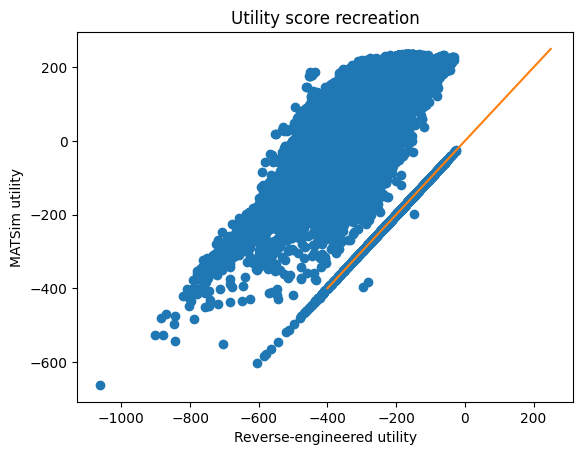

In [ ]:
plt.plot(df4["ep_calculated_total_u"], df4["selected plan utility"], "o")
plt.title("Utility score recreation")
plt.xlabel("Reverse-engineered utility")
plt.ylabel("MATSim utility")
x = np.linspace(-400, 250,5)
plt.plot(x,x)

the below is for plotting when size is too big and cant use matplotlib directly

In [ ]:
# import datashader as ds
# import datashader.transfer_functions as tf
# import colorcet as cc

# x_min, x_max = dd.compute(
#     df3['selected plan utility'].min(),
#     df3['selected plan utility'].max()
# )
# y_min, y_max = dd.compute(
#     df3['ep_calculated_total_u'].min(),
#     df3['ep_calculated_total_u'].max()
# )

# # 1. Create the datashader canvas (sets resolution)
# canvas = ds.Canvas(plot_width=800, plot_height=600, x_range=(x_min, x_max), y_range=(y_min, y_max))

# # 2. Aggregate the dask dataframe into a 2D histogram
# agg = canvas.points(df3, x='selected plan utility', y='ep_calculated_total_u')

# # 3. Shade the aggregation into an image
# # img = tf.shade(agg, cmap='inferno', how='log')  # 'log', 'linear', or 'eq_hist'
# img = tf.shade(agg, cmap=cc.fire, how='linear')

# # 4. Convert to numpy array for matplotlib
# img_arr = np.array(img.to_pil())

# # 5. Plot with matplotlib
# fig, ax = plt.subplots(figsize=(10, 7))
# ax.imshow(
#     img_arr,
#     # extent=[float(df3['selected plan utility'].min()), float(df3['selected plan utility'].max()),
#             # float(df3['ep_calculated_total_u'].min()), float(df3['ep_calculated_total_u'].max())],
#     aspect='auto',
#     origin='upper'

# )
# ax.set_xlabel('selected plan utility')
# ax.set_ylabel('ep_calculated_total_u')
# ax.set_title('Scatter (datashader + matplotlib)')
# plt.tight_layout()
# plt.show()

---
## Stage 2 — Compute Flex Scores from Parquet

Loads the parquet written in Stage 1. Columns are proper Arrow types
(`LIST<string>`, `LIST<int64>`, `LIST<double>`, etc.) — no string parsing needed anywhere.

### Load Parquet

In [ ]:
# Columns are proper Arrow types (LIST<string>, LIST<int64>, LIST<double>, etc.)
# — no string parsing needed anywhere in Stage 2.
# df_flex = dd.read_parquet("1905_2040_keep_0.1pc_keep10_Ucalcs_test.parquet")
df_flex = df3

### Flex Score Helper Functions

In [ ]:
import ast
import scipy.stats as sp

In [ ]:
def summariseAdjacentLegs(trips):
    return [
        [[item for i, item in enumerate(sublist_j) if i == 0 or item != sublist_j[i-1]]
         for sublist_j in sublist_i]
        for sublist_i in trips
    ]


def trips_to_keep(modes, travel_u, activity_u):
    if not modes:
        return [], [], []
    if not (len(modes) == len(travel_u) == len(activity_u)):
        raise ValueError("All three lists must have the same length")
    if len(modes) == 1:
        return [tuple(modes[0]) if isinstance(modes[0], list) else modes[0]], [travel_u[0]], [activity_u[0]]

    modes_fixed = [tuple(m) if isinstance(m, list) else m for m in modes]
    first_key = modes_fixed[0]
    best = {}
    for idx in range(1, len(modes_fixed)):
        k = modes_fixed[idx]
        if k == first_key:
            continue
        v = travel_u[idx]
        if k not in best or v > best[k][0] or (v == best[k][0] and idx < best[k][1]):
            best[k] = (v, idx)

    chosen = [best[k][1] for k in sorted(best, key=lambda kk: best[kk][1])]
    return (
        [modes_fixed[0]] + [modes_fixed[i] for i in chosen],
        [travel_u[0]]   + [travel_u[i]    for i in chosen],
        [activity_u[0]] + [activity_u[i]  for i in chosen],
    )


def calculate_flex_score(modes, travel_u, activity_u):
    components = [] 
    #could be components = [np.zeros(len(modes))]
    k = 2.944
    beta = 0.037
    # print(type(travel_u))
    # print(type(activity_u))
    # print(travel_u)
    # print(activity_u)
    if isinstance(travel_u, str):
        travel_u = ast.literal_eval(travel_u)
    travel_u = [float(x) for x in travel_u]
    if isinstance(activity_u, str):
        activity_u = ast.literal_eval(activity_u)
    activity_u = [float(x) for x in activity_u]
    modes, travel_u, activity_u = trips_to_keep(modes, travel_u, activity_u)
    # print(modes)
    # print(travel_u)
    # print(activity_u)
    for i in range(1, len(modes)):
        try:
            activity_u_ratio = (activity_u[0]-activity_u[i])/activity_u[0]
        except ZeroDivisionError:
            activity_u_ratio = 0
        # print(f"activity u ratio: {activity_u_ratio}")
        try:
            travel_u_ratio = (travel_u[0]-travel_u[i])/travel_u[0]
        except ZeroDivisionError:
            travel_u_ratio = 0
        # print(f"travel u ratio: {travel_u_ratio}")
        if travel_u_ratio * activity_u_ratio >= 0:
            sigma = -1
        else:
            sigma = 1
        # print(f"sigma: {sigma}")
        temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio))))) 
        # print(f"temp: {temp}")
        components.append(temp)
        #then if would be components[i-1]=temp
    if len(components) == 0:
        f = 0
    else:
        # f = np.mean(components)
        f = sp.pmean(components, 2)
    return(f)


def calculate_flex_score_full(day_modes, day_travel_u, day_activity_u):
    return float(np.mean([
        calculate_flex_score(day_modes[i], day_travel_u[i], day_activity_u[i])
        for i in range(len(day_modes))
    ]))

### Compute Flex Scores

In [ ]:
def compute_flex_calcs_all(row: pd.Series, prefixes: list) -> dict:
    modes_list, travel_u_list, act_u_list = [], [], []
    for prefix in prefixes:
        plan_name = PLANS[prefix]
        modes_list.append(moa.group_legs_into_trips(
            row[f"{plan_name} activity_type_or_mode"],
            row[f"{prefix}_activities_indices"],
            row[f"{prefix}_stuck_index"],
        ))
        travel_u_list.append(row[f"{prefix}_calculated_travel_u"])
        act_u_list.append(row[f"{prefix}_calculated_activity_u"])

    trips_modes        = [list(pair) for pair in zip(*modes_list)]
    travel_utilities   = [list(pair) for pair in zip(*travel_u_list)]
    activity_utilities = [list(pair) for pair in zip(*act_u_list)]

    if any(x is None for x in activity_utilities):
        return {"trips_modes": None, "travel_utilities": None,
                "activity_utilities": None, "trips_modes_summarised": None, "f_score_full": np.nan}

    trips_modes_summarised = summariseAdjacentLegs(trips_modes)
    f_score_full = calculate_flex_score_full(trips_modes_summarised, travel_utilities, activity_utilities)
    return {
        "trips_modes":            trips_modes,
        "travel_utilities":       travel_utilities,
        "activity_utilities":     activity_utilities,
        "trips_modes_summarised": trips_modes_summarised,
        "f_score_full":           f_score_full,
    }


def process_partition(pdf: pd.DataFrame, prefixes: list) -> pd.DataFrame:
    results = pdf.apply(lambda row: compute_flex_calcs_all(row, prefixes), axis=1)
    res_df = pd.DataFrame(results.tolist(), index=pdf.index)
    return pd.concat([pdf, res_df], axis=1)


flex_prefixes = ["sp"] + [k for k in PLANS if k.startswith("up")]

sample_flex_out = process_partition(df_flex.head(5), flex_prefixes)
df_flex_result = df_flex.map_partitions(process_partition, prefixes=flex_prefixes, meta=sample_flex_out)
# df_flex_result = df_flex_result.dropna(subset=["f_score_full"])
# df_flex_result.to_parquet("1905_2040_flex_scores_test.parquet")

c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [29]:
# df_flex_result = df_flex_result.dropna(subset=["f_score_full"])
# df_flex_result.to_parquet("1905_2040_flex_scores_test.parquet")

In [ ]:
keep_df5 = [
    'id', 'subpopulation', 'hzone', 'stuck_bool',
    'selected plan activity_type_or_mode',  # Cell 52 (db_trips) + Cell 56 (home index)
    'selected plan location',               # Cell 56 home coords
    'sp_activities_indices',                # Cell 52 + 56
    'f_score_full',                         # everything downstream
    'trips_modes_summarised', 'travel_utilities', 'activity_utilities',  # flex intermediates
]

keep_df5 = [c for c in keep_df5 if c in df_flex_result.columns]
df5 = df_flex_result[keep_df5].compute()


In [ ]:
# df5.to_csv("0406_df5.csv")

In [ ]:
# df2.head(25)

,id,age,age_group,area_type,carAvail,car_avail,car_competition,disabled,ev,gender,...,unselected plan (8) duration,unselected plan (8) location,unselected plan (8) routes,unselected plan (8) boardingTime,unselected plan (9) activity_type_or_mode,unselected plan (9) distance_travelled,unselected plan (9) duration,unselected plan (9) location,unselected plan (9) routes,unselected plan (9) boardingTime
0,315,62.0,60 to 64,rural,yes,yes,1.00,no,False,female,...,10:05:16; 00:18:10; 11:30:14; 00:18:10; 23:37:16,"561866.0,222662.0; N/A; 561676.0,221989.0; N/A...",N/A; N/A; N/A; N/A; N/A,N/A; N/A; N/A; N/A; N/A,home; walk; other; walk; home,N/A; 909.0979100184974; N/A; 909.0979100184974...,09:54:28; 00:18:10; 11:18:51; 00:18:10; 23:37:48,"561866.0,222662.0; N/A; 561676.0,221989.0; N/A...",N/A; N/A; N/A; N/A; N/A,N/A; N/A; N/A; N/A; N/A
1,830,44.0,40 to 49,urban,yes,yes,1.00,no,True,female,...,08:13:24; 00:00:00; 17:05:40; 00:00:00; 20:31:...,"570476.0,206823.0; N/A; 570476.0,206823.0; N/A...",N/A; N/A; N/A; N/A; N/A; 5177147052759635893_5...,N/A; N/A; N/A; N/A; N/A; N/A; N/A,home; walk; work; walk; home; car; other,N/A; 0.0; N/A; 0.0; N/A; 4190.339350919564; N/A,08:13:24; 00:00:00; 17:05:40; 00:00:00; 20:31:...,"570476.0,206823.0; N/A; 570476.0,206823.0; N/A...",N/A; N/A; N/A; N/A; N/A; 5177147052759635893_5...,N/A; N/A; N/A; N/A; N/A; N/A; N/A
2,1168,34.0,30 to 39,urban,yes,yes,2.00,no,False,male,...,17:29:47; 00:34:14; 23:51:23,"520886.0,196162.0; N/A; 548585.0,215171.0",N/A; 101172 552091 590665 588843 5221385307084...,N/A; N/A; N/A,home; car; visit,N/A; 47467.37662652984; N/A,17:29:47; 00:29:41; 23:51:23,"520886.0,196162.0; N/A; 548585.0,215171.0",N/A; 101172 552091 590665 588843 5221385307084...,N/A; N/A; N/A
3,2013,54.0,50 to 59,urban,yes,yes,1.00,no,True,female,...,08:54:11; 00:03:56; 09:54:58; 00:49:10; 12:35:...,"593765.0,186047.0; N/A; 592177.0,185020.0; N/A...",N/A; 5177212928284148893_5177212928356898753 5...,N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A,home; car; visit; walk; home; taxi; other; tax...,N/A; 2276.5509031931692; N/A; 2458.50348179537...,08:51:45; 00:03:54; 09:43:32; 00:49:10; 12:47:...,"593765.0,186047.0; N/A; 592177.0,185020.0; N/A...",N/A; 5177212928284148893_5177212928356898753 5...,N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A
4,2213,54.0,50 to 59,rural,yes,yes,1.00,no,True,male,...,10:56:09; 00:18:28; 13:00:00; 00:04:20; 13:11:...,"637924.0,303897.0; N/A; 624895.0,311414.0; N/A...",N/A; 171224 241387 5177443113631238539_5177443...,N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A; N...,home; car; shop; car; visit; car; home; car; e...,N/A; 18528.916627513634; N/A; 3094.94873824132...,10:59:43; 00:20:46; 12:53:47; 00:04:20; 13:10:...,"637924.0,303897.0; N/A; 624895.0,311414.0; N/A...",N/A; 171224 241387 5177443113631238539_5177443...,N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A; N/A; N...
5,2310,28.0,26 to 29,rural,yes,yes,1.00,no,False,female,...,08:26:48; 00:34:08; 16:12:42; 00:00:00; 18:10:...,"562396.0,245281.0; N/A; 537776.0,263670.0; N/A...",N/A; 14286 179580 542335 603704 558677 5176994...,N/A; N/A; N/A; N/A; N/A; N/A; N/A,home; car; work; car; work; car; home,N/A; 33443.913814367115; N/A; 0.0; N/A; 33396....,08:26:48; 00:32:24; 16:12:42; 00:00:00; 18:10:...,"562396.0,245281.0; N/A; 537776.0,263670.0; N/A...",N/A; 14286 222808 26098 5176993969960943607_51...,N/A; N/A; N/A; N/A; N/A; N/A; N/A
6,3092,18.0,16 to 20,urban,yes,yes,1.00,no,False,female,...,13:39:05; 00:00:00; 22:36:10; 00:00:00; 24:09:10,"653596.0,291090.0; N/A; 653596.0,291090.0; N/A...",N/A; N/A; N/A; N/A; N/A,N/A; N/A; N/A; N/A; N/A,home; walk; work; walk; home,N/A; 0.0; N/A; 0.0; N/A,13:48:32; 00:00:00; 22:45:30; 00:00:00; 24:14:53,"653596.0,291090.0; N/A; 653596.0,291090.0; N/A...",N/A; N/A; N/A; N/A; N/A,N/A; N/A; N/A; N/A; N/A
7,3279,13.0,11 to 15,urban,yes,yes,1.00,no,True,female,...,14:12:02; 00:06:01; 16:23:01; 00:06:19; 25:01:51,"536172.0,214701.0; N/A; 538545.0,211912.0; N/A...",N/A; 371418 21967 4405 5221404412864263967_522...,N/A; N/A; N

---
## Analysis

### Load Results and Plot Histogram

c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

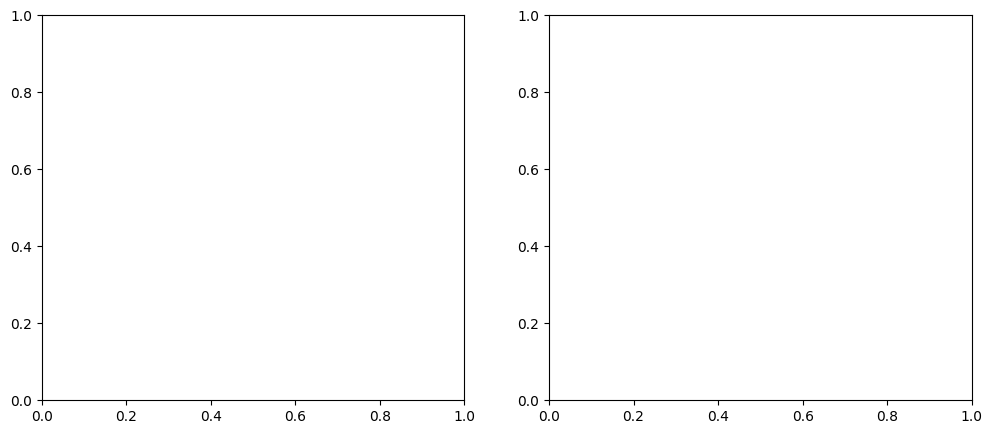

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2. First plot (Left side - axes[0])
axes[0].hist(df5["f_score_full"], bins=50)
axes[0].grid(True)
axes[0].set_xlabel("Flexibility score")
axes[0].set_ylabel("Count")
axes[0].set_title("Histogram of population-wide flexibility (0.1% population sample)")

# 3. Second plot (Right side - axes[1])
axes[1].hist(df5[df5["f_score_full"] > 0]["f_score_full"], bins=50)
axes[1].grid(True)
axes[1].set_xlabel("Flexibility score")
axes[1].set_ylabel("Count")
axes[1].set_title("Histogram of non-zero flexibility (0.1% population sample)")

# 4. Improve spacing so labels don't overlap
plt.tight_layout()
# plt.savefig("flex_distribuiton.png")
plt.show()


In [32]:
# #for the pandas df for ease
# plt.hist(df5[df5["f_score_full"]>0]["f_score_full"], bins=50)
# plt.grid()
# plt.title("flexibility score distribution for n=50, iters=5000")

In [ ]:
print(f"the total people is: {len(df5)}")
print(f"the percentage of people with zero scores is: {len(df5[df5["f_score_full"]==0])/len(df5) * 100}")

the total people is: 4436
the percentage of people with zero scores is: 80.13976555455365


In [ ]:
# df5["hzone"]

0       E09000002
1       E09000026
2       E09000022
3       E09000026
4       E02003732
          ...    
2213    E02004543
2214    E02004881
2215    E02005611
2216    E02006255
2217    E02004469
Name: hzone, Length: 4436, dtype: string

In [35]:
# #for the dask df for large data
# import datashader as ds
# import datashader.transfer_functions as tf

# # df_result = dd.read_parquet("1405_2040_flex_scores.parquet")

# df_hist = df_flex_result[["f_score_full"]].assign(y=1.0)
# canvas = ds.Canvas(plot_width=600, plot_height=1)
# agg = canvas.points(df_hist, x="f_score_full", y="y", agg=ds.count())

# hist_values = agg.values[0]
# x_bins = agg.coords["f_score_full"].values

# plt.figure(figsize=(10, 4))
# plt.bar(x_bins, hist_values, width=(x_bins[1] - x_bins[0]), color="steelblue", edgecolor="none")
# plt.xlabel("f_score_full")
# plt.ylabel("Count")
# plt.title("Histogram of f_score_full")
# plt.tight_layout()
# plt.show()

### Testing to see how number of unchosen plans affects zero proportion

In [25]:
results = {}
for n in [1, 2, 3, 4, 5, 10, 15, 19, 25, 30, 35, 40, 45, 49]:
    prefixes = ["sp"] + [f"up{i+1}" for i in range(n)]
    result = process_partition(df4, prefixes)   # df4 is already pandas — fast
    total = len(result)
    zeros = (result["f_score_full"] == 0).sum()
    results[n] = zeros / total * 100
    print(f"n_unselected={n:>2}: {results[n]:.2f}% zeros")




c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


n_unselected= 1: 86.61% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


n_unselected= 2: 83.61% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

n_unselected=40: 71.03% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_27408\604900273.py:70: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


n_unselected=45: 70.81% zeros


c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\maria\Documents\londinium\scoring\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\maria\AppData\Local\Temp\ipykernel_27408\604900273.py:70: RuntimeWarning: overflow encountered in exp
  temp = (2/(1+np.exp(k*abs(travel_u_ratio)*np.exp(sigma*beta*abs(activity_u_ratio)))))


n_unselected=49: 70.31% zeros


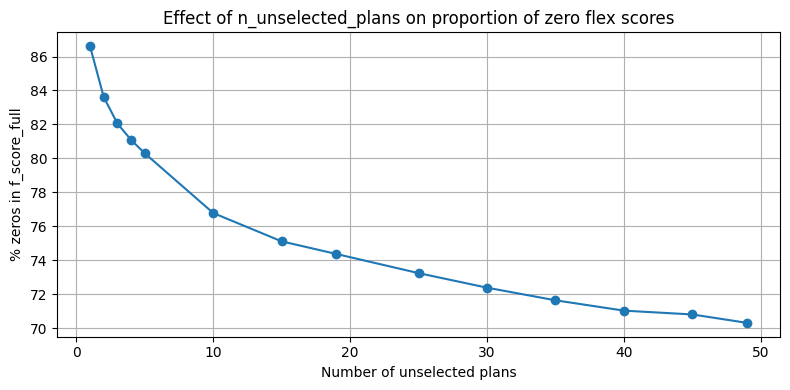

In [26]:
# plot it
plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Number of unselected plans")
plt.ylabel("% zeros in f_score_full")
plt.title("Effect of n_unselected_plans on proportion of zero flex scores")
plt.grid()
plt.tight_layout()
plt.show()

### CD Stats

In [27]:
# df5.to_csv("0406_50plans_100iters_0.1pc_Fscores.csv")

Now do analysis for abstract on these:
* ~~ get car only stats ~~ 
* drop unnecessary columns
* make density map of flex and CD
* make bivariate map of connectivity / flexibility (aggregate connectivity to MSOA)
* make bivariate map of connectivity / CD (aggregate connectivity to MSOA)
* check I'm calculating flex score correctly (including zeros in average or not??)

In [ ]:
def list_of_modes(activity_type_or_mode, activity_indices):
    legs = [val for i, val in enumerate(activity_type_or_mode) if i not in activity_indices]
    return legs
def check_for_modes(modes, target):
    all_tareget_bool = int(all(item == target for item in modes))
    return all_tareget_bool
def check_for_any_car_modes(modes, target_list):
    all_tareget_bool = int(any(item in target_list for item in modes))
    return all_tareget_bool

df5_cd = df5[df5["f_score_full"]==0]
df5_nocd = df5[df5["f_score_full"]>0]

df5_cd["db_trips"] = df5_cd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
df5_nocd["db_trips"] = df5_nocd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
df5_cd["all_car"] = df5_cd.apply(lambda row: check_for_modes(row["db_trips"], "car"), axis=1)
df5_cd["some_car"] = df5_cd.apply(lambda row: check_for_any_car_modes(row["db_trips"], ["car"]), axis=1)

df5_nocd["all_car"] = df5_nocd.apply(lambda row: check_for_modes(row["db_trips"], "car"), axis=1)
df5_nocd["some_car"] = df5_nocd.apply(lambda row: check_for_any_car_modes(row["db_trips"], ["car"]), axis=1)

C:\Users\maria\AppData\Local\Temp\ipykernel_38344\820964670.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df5_cd["db_trips"] = df5_cd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
C:\Users\maria\AppData\Local\Temp\ipykernel_38344\820964670.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df5_nocd["db_trips"] = df5_nocd.apply(lambda row: list_of_modes(row["selected plan activity_type_or_mode"], row["sp_activities_indices"]), axis=1)
C:\Users\maria\App

In [ ]:
print(f"The number of zero flexers with all car trips is: {sum(df5_cd["all_car"])} which is {(sum(df5_cd["all_car"])/len(df5_cd))*100}. This is {(sum(df5_cd["all_car"])/len(df5))*100}% of the whole population.")
print(f"The number of zero flexers with some car trips is: {sum(df5_cd["some_car"])} which is {(sum(df5_cd["some_car"])/len(df5_cd))*100}. This is {(sum(df5_cd["some_car"])/len(df5))*100}% of the whole population.")

The number of zero flexers with all car trips is: 1906 which is 53.614627285513365. This is 42.966636609558165% of the whole population.
The number of zero flexers with some car trips is: 2229 which is 62.70042194092827. This is 50.24797114517583% of the whole population.


In [ ]:
df5_cd["all_walk"] = df5_cd.apply(lambda row: check_for_modes(row["db_trips"], "walk"), axis=1)
print(f"The number of zero flexers with all walk trips is: {sum(df5_cd["all_walk"])} which is {(sum(df5_cd["all_walk"])/len(df5_cd))*100}. This is {(sum(df5_cd["all_walk"])/len(df5))*100}% of the whole population.")

### Make maps

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
from pyproj import Transformer
import h3

In [ ]:
def get_home_index(item_list):
    index = [i for i, val in enumerate(item_list) if val == 'home']
    return index if index else [0] # get the index of where home is if there is a home. if no home, return index 0 (first location)
def get_home_coords(values, indices):
    if not indices:
        return pd.NA
    if not isinstance(values, list) or not isinstance(indices, list):
        raise TypeError("Both values and indices should be lists")

    first_index = indices[0]
    if 0 <= first_index < len(values):
        return values[first_index]
    else:
        return pd.NA
    
def parse_coords(coord_str):
    try:
        if not isinstance(coord_str, str) or ',' not in coord_str:
            return None
        x_str, y_str = coord_str.split(',')
        x, y = float(x_str.strip()), float(y_str.strip())
        return Point(x, y)
    except:
        return None
    
df5["home_index"] = df5['selected plan activity_type_or_mode'].apply(get_home_index)
df5["home_coords"] = df5.apply(lambda row: get_home_coords(row['selected plan location'], row['home_index']), axis=1)
df5[['home_x', 'home_y']] = df5['home_coords'].str.split(',', expand=True).astype(float)
df5['geometry'] = df5['home_coords'].apply(parse_coords)
df5 = df5[df5['geometry'].notnull()].copy()

resolution = 9
transformer = Transformer.from_crs("epsg:27700", "epsg:4326", always_xy=True)
df5["long"], df5["lat"] = transformer.transform(df5['home_x'].values, df5['home_y'].values)
df5['hex_id'] = df5.apply(lambda r: h3.latlng_to_cell(r['lat'], r['long'], resolution), axis=1)

gdf = gpd.GeoDataFrame(df5, geometry='geometry', crs="EPSG:27700")  
gdf_nonzero = gpd.GeoDataFrame(df5, geometry='geometry', crs="EPSG:27700")  

In [ ]:
msoas = gpd.read_file(r"C:\Users\maria\Documents\matsim_analysis\data\MSOA_2021_EW\MSOA_2021_EW_BSC_V3.shp")
msoa_lsoa_lookup = pd.read_csv(r"C:\Users\maria\OneDrive - University College London\Documents\Data\DfT\PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU\PCD_OA21_LSOA21_MSOA21_LAD_MAY25_UK_LU.csv")
connectivity = pd.read_csv(r"C:\Users\maria\OneDrive - University College London\Documents\Data\DfT\connectivity_metrics_2025_LSOA.csv", skiprows=2)

In [ ]:
gdf = gpd.sjoin(gdf, msoas, how="left", predicate="within")
gdf_nonzero = gdf[gdf["f_score_full"]>0]

In [ ]:
mean_flex = gdf.groupby('MSOA21CD')['f_score_full'].mean().reset_index()
median_flex = gdf.groupby('MSOA21CD')['f_score_full'].median().reset_index()

# 6. Merge the median values back to the MSOA map
msoa_mean = msoas.merge(mean_flex, on='MSOA21CD', how='left')
msoa_median = msoas.merge(median_flex, on='MSOA21CD', how='left')

xmin, ymin, xmax, ymax = gdf.total_bounds

In [ ]:
mean_flex_nonzero = gdf_nonzero.groupby('MSOA21CD')['f_score_full'].mean().reset_index()
median_flex_nonzero = gdf_nonzero.groupby('MSOA21CD')['f_score_full'].median().reset_index()

# 6. Merge the median values back to the MSOA map
msoa_mean_nonzero = msoas.merge(mean_flex_nonzero, on='MSOA21CD', how='left')
msoa_median_nonzero = msoas.merge(median_flex_nonzero, on='MSOA21CD', how='left')

xmin_nonzero, ymin_nonzero, xmax_nonzero, ymax_nonzero = gdf_nonzero.total_bounds

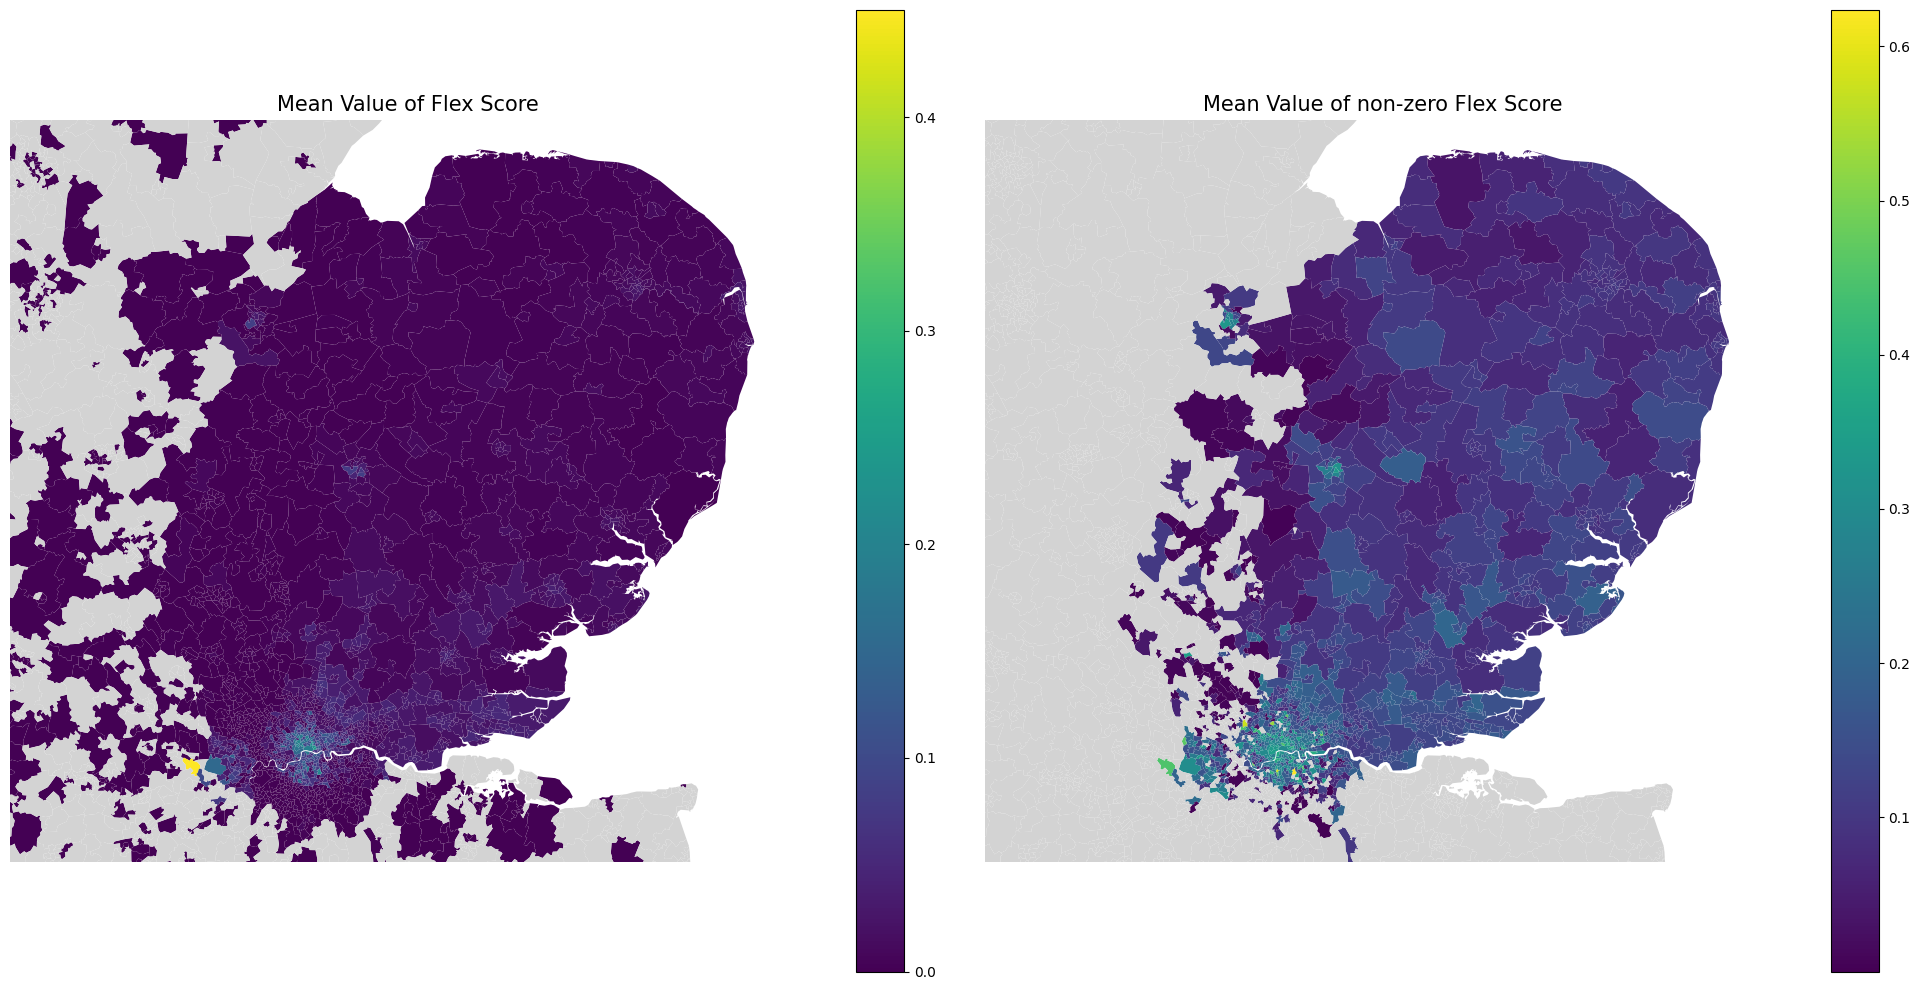

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# 1. Create the 1x2 figure
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(20, 10))
# fig, ax1 = plt.subplots(1, 1, figsize=(10, 10))

# Define your zoom area (adjust these to your specific Eastings/Northings)
z_xmin, z_xmax = 500000, 550000 
z_ymin, z_ymax = 160000, 195000

# --- MAP 1: MEAN ---
msoa_mean_nonzero.plot(column='f_score_full', ax=ax1, legend=True, cmap='viridis',
               missing_kwds={'color': 'lightgrey'})
ax1.set_title('Mean Value of non-zero Flex Score', fontsize=15)
ax1.axis('off')
ax1.set_xlim(450000, 670000)
ax1.set_ylim(150000, 355000)

# --- MAP 2: MEAN ---
msoa_mean.plot(column='f_score_full', ax=ax2, legend=True, cmap='viridis',
               missing_kwds={'color': 'lightgrey'})
ax2.set_title('Mean Value of Flex Score', fontsize=15)
ax2.axis('off')
# ax1.set_xlim(xmin, xmax)
# ax1.set_ylim(ymin, ymax)
ax2.set_xlim(450000, 670000)
ax2.set_ylim(150000, 355000)

plt.tight_layout()
# plt.savefig("mean_flex_score_MSOA_both.png")
plt.show()


In [ ]:
msoa_lsoa_lookup.columns = msoa_lsoa_lookup.columns.str.upper()